# Estadísticas de los datos.

## Librerías.

In [1]:
import pandas as pd
import numpy as np
from joblib import load
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

## Datos.

In [21]:
in_file = "data_clean/DALYs_clean_unificado_NEW.pkl"
with open(in_file, 'rb') as f:
    df = load(f)

print(f"Dimensiones: {df.shape}")
print(f"Columnas disponibles: {df.columns.tolist()}")

Dimensiones: (242956, 26)
Columnas disponibles: ['ano', 'pais', 'codigo_pais', 'codigo_ghe', 'categoria_principal', 'categoria_nivel1', 'categoria_nivel2', 'causa', 'sexo', 'edad', 'dalys', 'pib_per_capita', 'idh', 'indice_educacion', 'indice_salud', 'indice_ingresos', 'esperanza_vida', 'poblacion_miles', 'co2_anual', 'precipitacion_total', 'temperatura_superficial', 'humedad_relativa', 'poblacion_abs', 'tasa_dalys_100k', 'dalys_por_intervencion', 'desarrollo_vs_carga']


## Cálculo e integración de estadísticas.

### Estadísticas descriptivas.

#### Población absoluta por país y año.

In [22]:
poblacion_media_anual = df.groupby(['ano', 'pais'])['poblacion_abs'].mean().round(4)
poblacion_mediana_anual = df.groupby(['ano', 'pais'])['poblacion_abs'].median()
poblacion_moda_anual = df.groupby(['ano', 'pais'])['poblacion_abs'].agg(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None
)

# Imprimir solo donde hay datos
for (ano, pais), media in poblacion_media_anual.items():
    if not pd.isna(media):  # Solo mostrar donde hay datos
        mediana = poblacion_mediana_anual[(ano, pais)]
        moda = poblacion_moda_anual[(ano, pais)]
        
        print(f"Año: {ano}, País: {pais}")
        print(f"\tMedia: {media:.4f}")
        print(f"\tMediana: {mediana:.4f}")
        if moda:
            print(f"\tModa: {moda:.4f}")
        print()

Año: 2000, País: Afghanistan
	Media: 1437881.1429
	Mediana: 1651588.5000
	Moda: 111378.0000

Año: 2000, País: Albania
	Media: 226154.1429
	Mediana: 142845.5000
	Moda: 60891.0000

Año: 2000, País: Algeria
	Media: 2207421.5714
	Mediana: 1522530.0000
	Moda: 391502.0000

Año: 2000, País: Armenia
	Media: 223259.5714
	Mediana: 134354.5000
	Moda: 63089.0000

Año: 2000, País: Australia
	Media: 1366605.4286
	Mediana: 1109325.0000
	Moda: 625445.0000

Año: 2000, País: Austria
	Media: 572352.0000
	Mediana: 483652.5000
	Moda: 204666.0000

Año: 2000, País: Azerbaijan
	Media: 583913.7143
	Mediana: 326164.0000
	Moda: 91702.0000

Año: 2000, País: Bahrain
	Media: 47828.5714
	Mediana: 35118.5000
	Moda: 4174.0000

Año: 2000, País: Bangladesh
	Media: 9610308.3571
	Mediana: 8870241.0000
	Moda: 1269048.0000

Año: 2000, País: Barbados
	Media: 18720.8571
	Mediana: 12763.5000
	Moda: 7809.0000

Año: 2000, País: Belarus
	Media: 713665.7143
	Mediana: 621156.5000
	Moda: 223889.0000

Año: 2000, País: Belgium
	Media:

C:\Users\troop\AppData\Local\Temp\ipykernel_14012\1862280544.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poblacion_media_anual = df.groupby(['ano', 'pais'])['poblacion_abs'].mean().round(4)
C:\Users\troop\AppData\Local\Temp\ipykernel_14012\1862280544.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poblacion_mediana_anual = df.groupby(['ano', 'pais'])['poblacion_abs'].median()
C:\Users\troop\AppData\Local\Temp\ipykernel_14012\1862280544.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

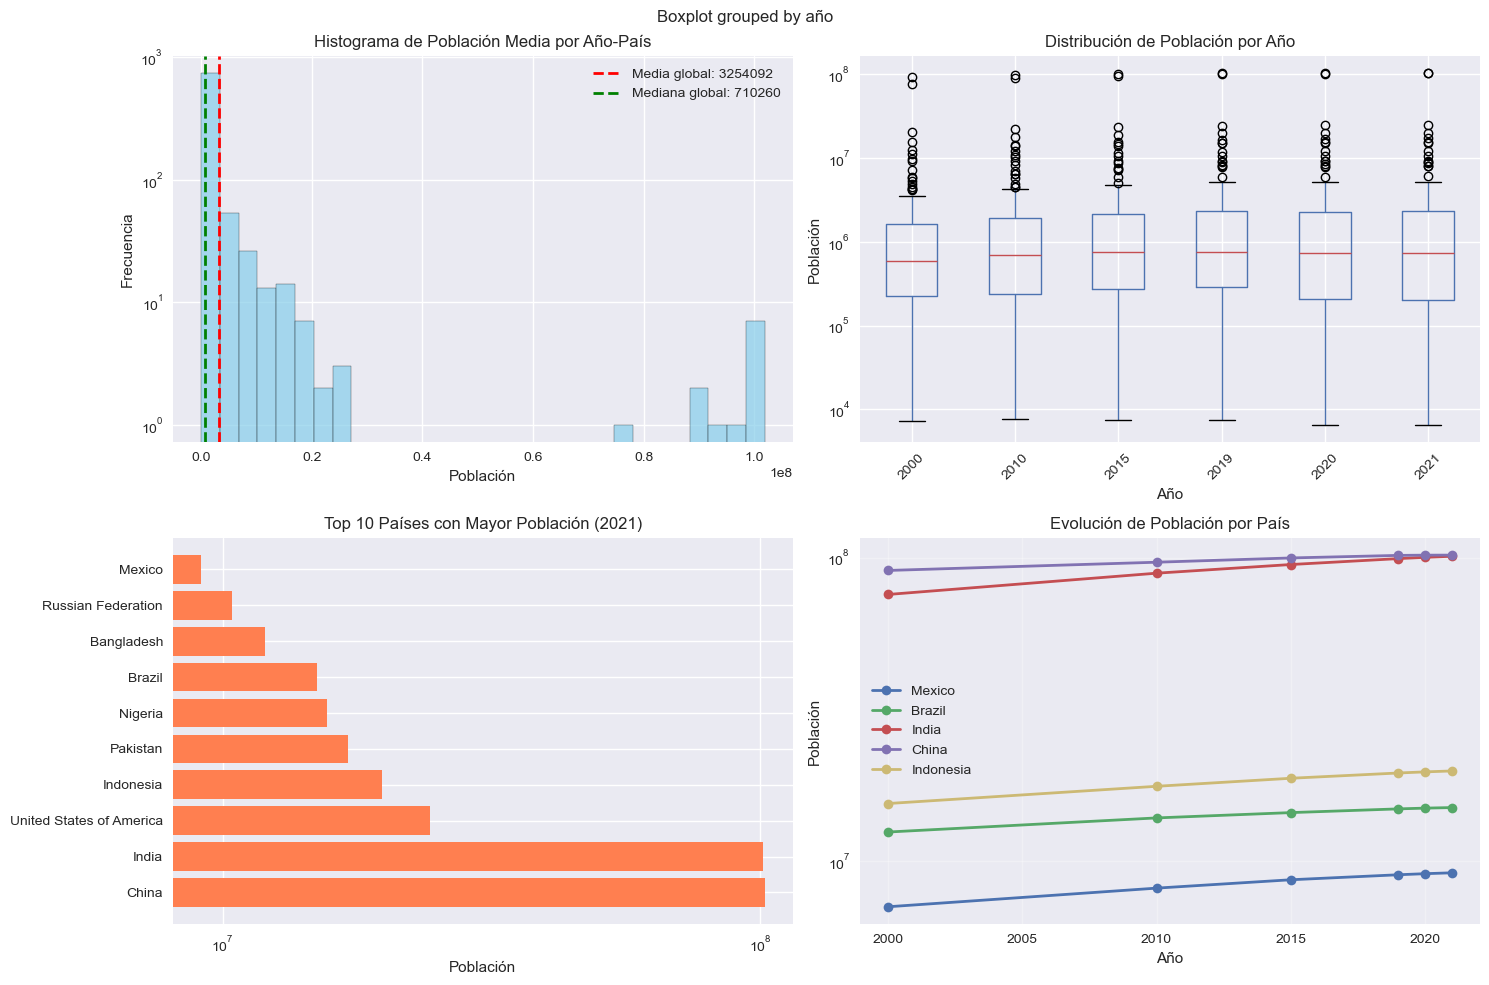

In [37]:
# Configurar estilo
plt.style.use('seaborn-v0_8')  

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribución de Población por Año y País', fontsize=16)

# 1. Histograma de todas las medias
axes[0, 0].hist(poblacion_media_anual.values, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(poblacion_media_anual.mean(), color='red', linestyle='--', linewidth=2, label=f'Media global: {poblacion_media_anual.mean():.0f}')
axes[0, 0].axvline(poblacion_media_anual.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana global: {poblacion_media_anual.median():.0f}')
axes[0, 0].set_xlabel('Población')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Histograma de Población Media por Año-País')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')  # Escala logarítmica para mejor visualización

# 2. Boxplot por año (necesitas reorganizar datos)
# Crear DataFrame con los datos
df_plot = pd.DataFrame({
    'año': [idx[0] for idx in poblacion_media_anual.index],
    'pais': [idx[1] for idx in poblacion_media_anual.index],
    'media': poblacion_media_anual.values
})

# Boxplot por año
df_plot.boxplot(column='media', by='año', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Población por Año')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Población')
axes[0, 1].set_yscale('log')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Top 10 países con mayor población (último año disponible)
ultimo_ano = df_plot['año'].max()
top_paises = df_plot[df_plot['año'] == ultimo_ano].nlargest(10, 'media')
axes[1, 0].barh(range(len(top_paises)), top_paises['media'].values, color='coral')
axes[1, 0].set_yticks(range(len(top_paises)))
axes[1, 0].set_yticklabels(top_paises['pais'].values)
axes[1, 0].set_xlabel('Población')
axes[1, 0].set_title(f'Top 10 Países con Mayor Población ({ultimo_ano})')
axes[1, 0].set_xscale('log')

# 4. Evolución temporal de algunos países seleccionados
paises_interes = ['Mexico', 'Brazil', 'India', 'China', 'Indonesia']  # Cambia según tus datos
df_evolucion = df_plot[df_plot['pais'].isin(paises_interes)]

for pais in paises_interes:
    datos_pais = df_evolucion[df_evolucion['pais'] == pais].sort_values('año')
    axes[1, 1].plot(datos_pais['año'], datos_pais['media'], marker='o', linewidth=2, label=pais)

axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Población')
axes[1, 1].set_title('Evolución de Población por País')
axes[1, 1].legend()
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### DALYs totales por país y año.

In [23]:
dalys_media_anual = df.groupby(['ano', 'pais'])['dalys'].mean().round(4)
dalys_mediana_anual = df.groupby(['ano', 'pais'])['dalys'].median()
dalys_moda_anual = df.groupby(['ano', 'pais'])['dalys'].agg(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None
)

# Imprimir solo donde hay datos
for (ano, pais), media in dalys_media_anual.items():
    if not pd.isna(media):  # Solo mostrar donde hay datos
        mediana = dalys_mediana_anual[(ano, pais)]
        moda = dalys_moda_anual[(ano, pais)]
        
        print(f"Año: {ano}, País: {pais}")
        print(f"\tMedia: {media:.4f}")
        print(f"\tMediana: {mediana:.4f}")
        if moda:
            print(f"\tModa: {moda:.4f}")
        print()

Año: 2000, País: Afghanistan
	Media: 1.3132
	Mediana: 0.0010

Año: 2000, País: Albania
	Media: 0.0081
	Mediana: 0.0000

Año: 2000, País: Algeria
	Media: 0.1638
	Mediana: 0.0014

Año: 2000, País: Armenia
	Media: 0.0051
	Mediana: 0.0000

Año: 2000, País: Australia
	Media: 0.0022
	Mediana: 0.0000

Año: 2000, País: Austria
	Media: 0.0033
	Mediana: 0.0000

Año: 2000, País: Azerbaijan
	Media: 0.0213
	Mediana: 0.0000

Año: 2000, País: Bahrain
	Media: 0.0000
	Mediana: 0.0000

Año: 2000, País: Bangladesh
	Media: 5.0558
	Mediana: 0.2094

Año: 2000, País: Barbados
	Media: 0.0009
	Mediana: 0.0000

Año: 2000, País: Belarus
	Media: 0.0107
	Mediana: 0.0000

Año: 2000, País: Belgium
	Media: 0.0000
	Mediana: 0.0000

Año: 2000, País: Belize
	Media: 0.0011
	Mediana: 0.0000

Año: 2000, País: Benin
	Media: 5.0545
	Mediana: 0.0524

Año: 2000, País: Botswana
	Media: 0.0680
	Mediana: 0.0000

Año: 2000, País: Brazil
	Media: 4.9377
	Mediana: 0.5564

Año: 2000, País: Brunei Darussalam
	Media: 0.0012
	Mediana: 0.

C:\Users\troop\AppData\Local\Temp\ipykernel_14012\2307942975.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_media_anual = df.groupby(['ano', 'pais'])['dalys'].mean().round(4)
C:\Users\troop\AppData\Local\Temp\ipykernel_14012\2307942975.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_mediana_anual = df.groupby(['ano', 'pais'])['dalys'].median()
C:\Users\troop\AppData\Local\Temp\ipykernel_14012\2307942975.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True 

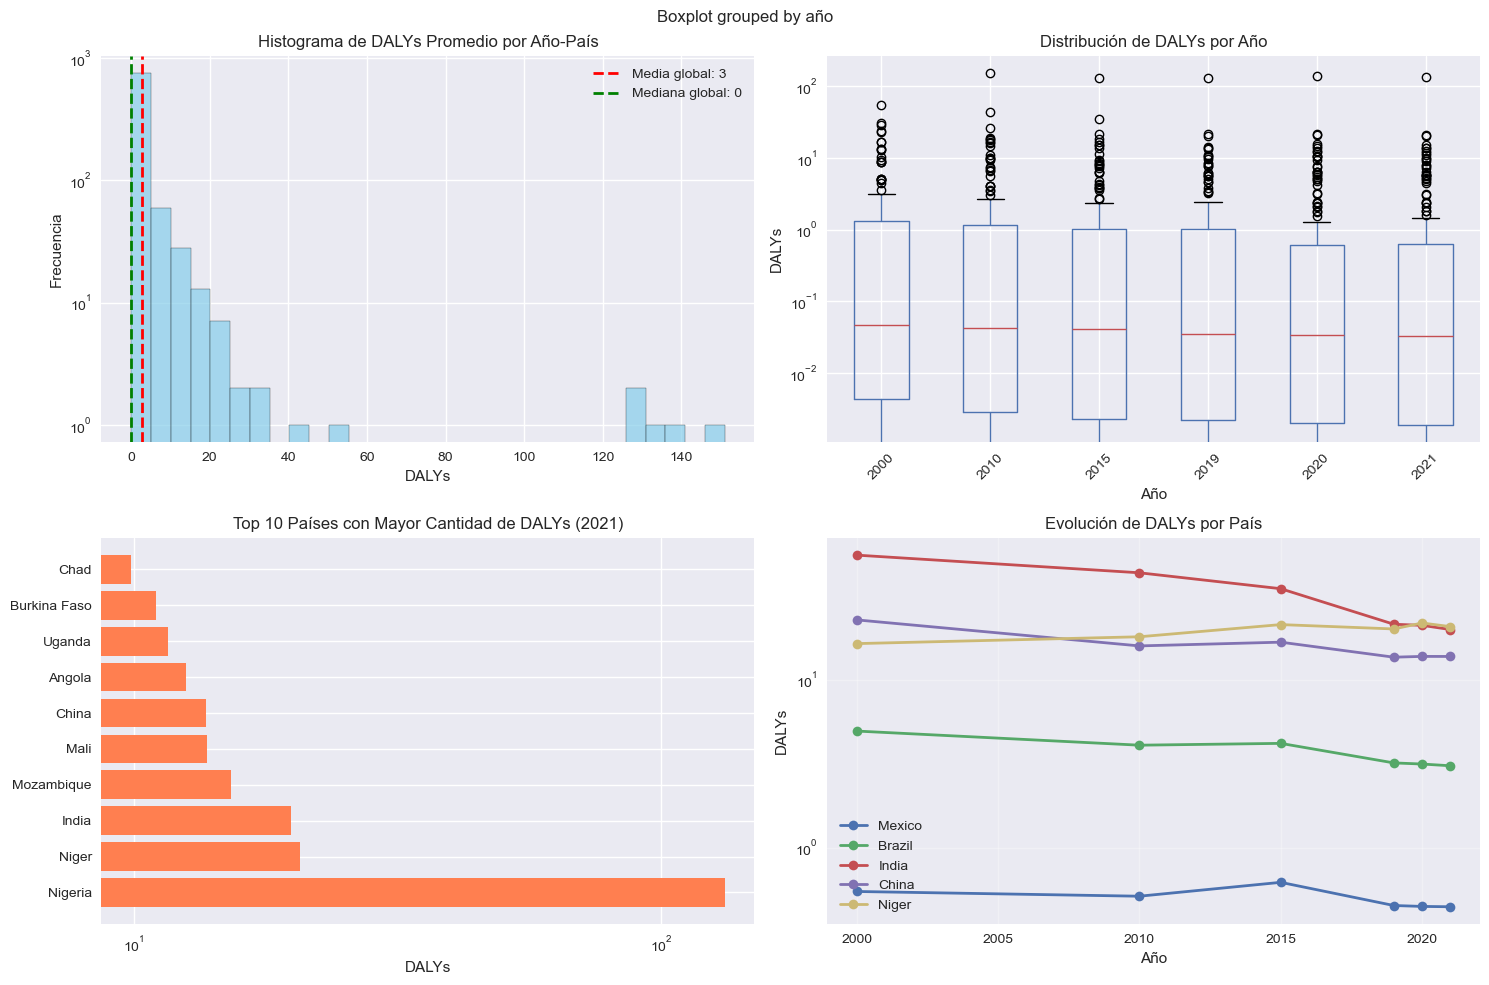

In [38]:
# Configurar estilo
plt.style.use('seaborn-v0_8')  

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribución de DALYs por Año y País', fontsize=16)

# 1. Histograma de todas las medias
axes[0, 0].hist(dalys_media_anual.values, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(dalys_media_anual.mean(), color='red', linestyle='--', linewidth=2, label=f'Media global: {dalys_media_anual.mean():.0f}')
axes[0, 0].axvline(dalys_media_anual.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana global: {dalys_media_anual.median():.0f}')
axes[0, 0].set_xlabel('DALYs')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Histograma de DALYs Promedio por Año-País')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')  # Escala logarítmica para mejor visualización

# 2. Boxplot por año (necesitas reorganizar datos)
# Crear DataFrame con los datos
df_plot = pd.DataFrame({
    'año': [idx[0] for idx in dalys_media_anual.index],
    'pais': [idx[1] for idx in dalys_media_anual.index],
    'media': dalys_media_anual.values
})

# Boxplot por año
df_plot.boxplot(column='media', by='año', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de DALYs por Año')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('DALYs')
axes[0, 1].set_yscale('log')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Top 10 países con mayor población (último año disponible)
ultimo_ano = df_plot['año'].max()
top_paises = df_plot[df_plot['año'] == ultimo_ano].nlargest(10, 'media')
axes[1, 0].barh(range(len(top_paises)), top_paises['media'].values, color='coral')
axes[1, 0].set_yticks(range(len(top_paises)))
axes[1, 0].set_yticklabels(top_paises['pais'].values)
axes[1, 0].set_xlabel('DALYs')
axes[1, 0].set_title(f'Top 10 Países con Mayor Cantidad de DALYs ({ultimo_ano})')
axes[1, 0].set_xscale('log')

# 4. Evolución temporal de algunos países seleccionados
paises_interes = ['Mexico', 'Brazil', 'India', 'China', 'Niger']  # Cambia según tus datos
df_evolucion = df_plot[df_plot['pais'].isin(paises_interes)]

for pais in paises_interes:
    datos_pais = df_evolucion[df_evolucion['pais'] == pais].sort_values('año')
    axes[1, 1].plot(datos_pais['año'], datos_pais['media'], marker='o', linewidth=2, label=pais)

axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('DALYs')
axes[1, 1].set_title('Evolución de DALYs por País')
axes[1, 1].legend()
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Distribución de los datos.

C:\Users\troop\AppData\Local\Temp\ipykernel_14012\2898748535.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dalys_por_pais_ano = df.groupby(['ano', 'pais'])['dalys'].mean().reset_index()


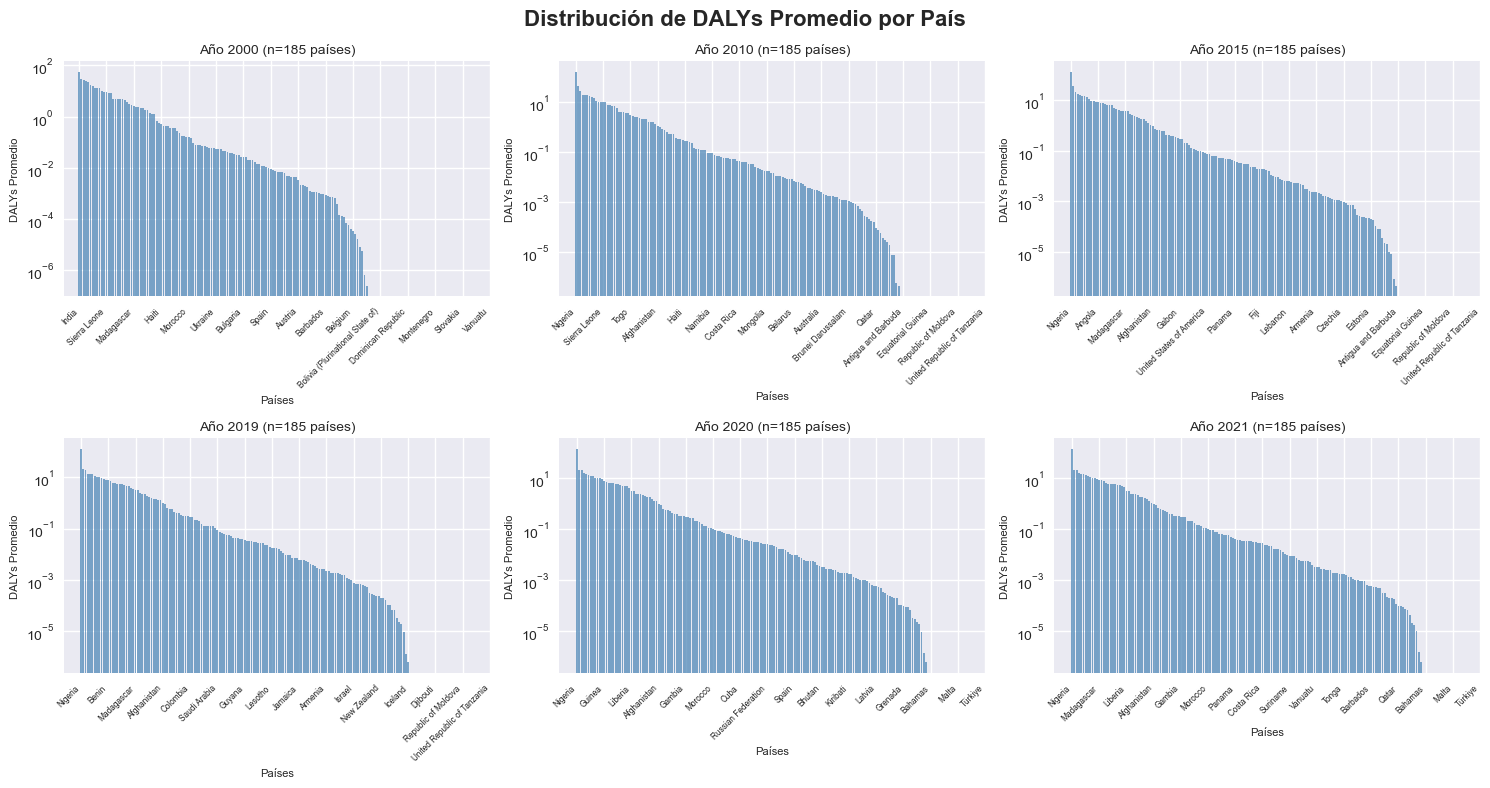

In [25]:
# Histograma de DALYs promedio por año-país
dalys_por_pais_ano = df.groupby(['ano', 'pais'])['dalys'].mean().reset_index()
dalys_por_pais_ano.columns = ['ano', 'pais', 'dalys_promedio']

# Calcular número de subplots necesario
anos = sorted(dalys_por_pais_ano['ano'].unique())
n_anos = len(anos)

# Calcular layout óptimo (más cuadrado posible)
n_cols = int(np.ceil(np.sqrt(n_anos)))
n_rows = int(np.ceil(n_anos / n_cols))

# Crear figura con tamaño dinámico
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
fig.suptitle('Distribución de DALYs Promedio por País', fontsize=16, fontweight='bold')

# Aplanar axes si es necesario
if n_anos > 1:
    axes = axes.flatten()
else:
    axes = [axes]

for idx, ano in enumerate(anos):
    ax = axes[idx]
    
    # Filtrar datos del año
    datos_ano = dalys_por_pais_ano[dalys_por_pais_ano['ano'] == ano]
    
    # Ordenar por DALYs descendente
    datos_ano = datos_ano.sort_values('dalys_promedio', ascending=False)
    
    # Crear barras (cada país es una barra)
    ax.bar(range(len(datos_ano)), datos_ano['dalys_promedio'].values, alpha=0.7, color='steelblue')
    ax.set_title(f'Año {ano} (n={len(datos_ano)} países)', fontsize=10)
    ax.set_xlabel('Países', fontsize=8)
    ax.set_ylabel('DALYs Promedio', fontsize=8)
    ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=90)
    
    # Mostrar solo cada cierto número de países
    step = max(1, len(datos_ano) // 15)
    ax.set_xticks(range(0, len(datos_ano), step))
    ax.set_xticklabels(datos_ano['pais'].iloc[::step].values, rotation=45, ha='right', fontsize=6)

# Ocultar subplots no utilizados
for idx in range(n_anos, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Estadísticas por año:
      mean  median
ano               
2000  2.71    0.05
2010  3.21    0.04
2015  2.83    0.04
2019  2.55    0.03
2020  2.56    0.03
2021  2.48    0.03


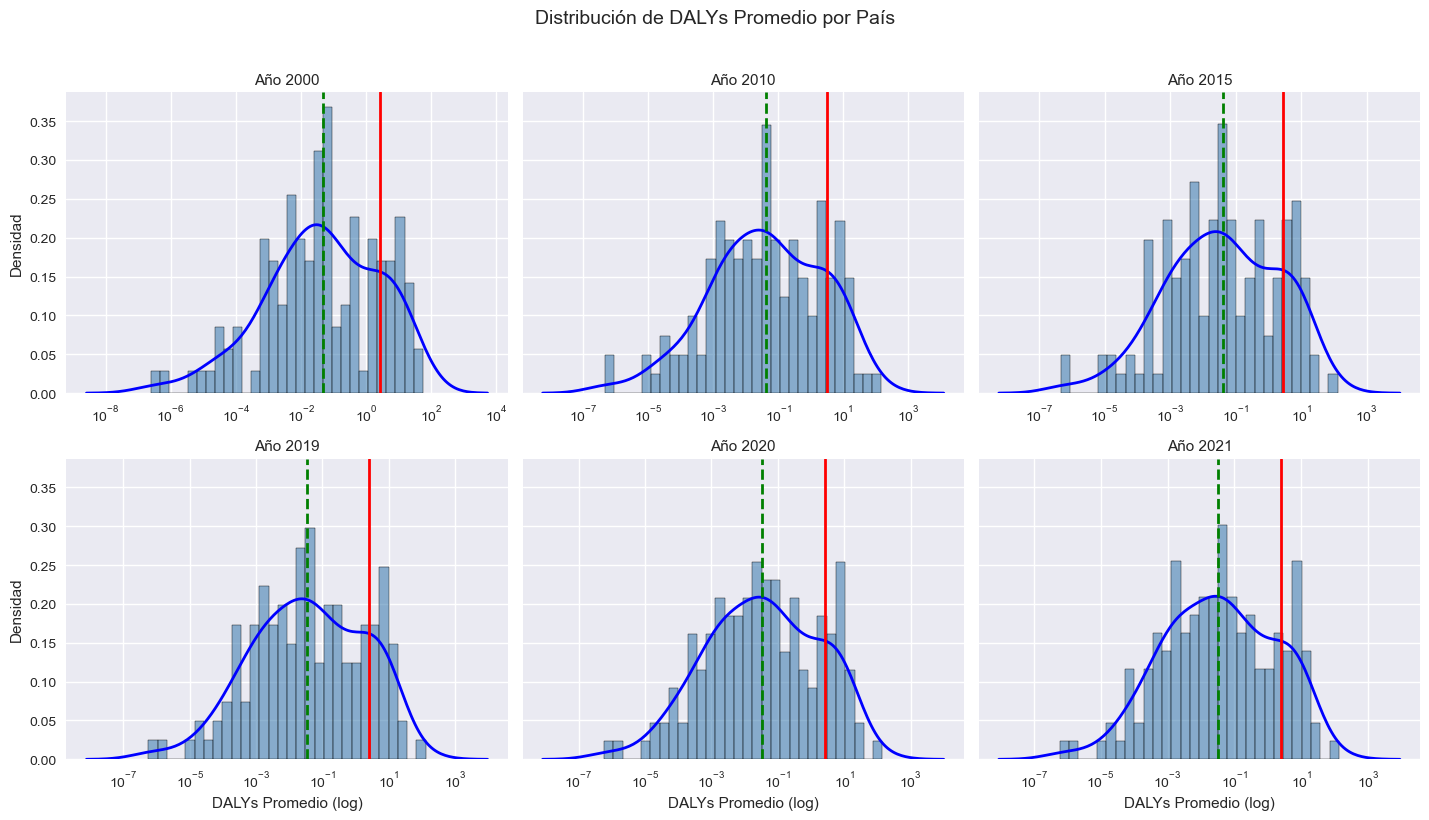

In [36]:
estadisticas_por_ano = dalys_por_pais_ano.groupby('ano')['dalys_promedio'].agg(['mean', 'median']).round(2)
print("Estadísticas por año:")
print(estadisticas_por_ano)

# Función personalizada para agregar estadísticas
def plot_with_stats(data, **kwargs):
    """Grafica histograma + KDE con líneas de estadísticas"""
    # Graficar histograma y KDE
    sns.histplot(data, **kwargs)
    sns.kdeplot(data, color='blue', linewidth=2, log_scale=True)
    
    # Calcular estadísticas
    media = data.mean()
    mediana = data.median()
    
    # Agregar líneas verticales
    plt.axvline(media, color='red', linestyle='-', linewidth=2, label=f'Media: {media:.2f}')
    plt.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
    
    plt.legend(loc='upper right', fontsize=7)


# Crear FacetGrid
g = sns.FacetGrid(dalys_por_pais_ano, col='ano', col_wrap=3, 
                  height=4, aspect=1.2, sharex=False)

# Aplicar función personalizada
g.map(plot_with_stats, 'dalys_promedio', bins=30, log_scale=True, 
      color='steelblue', alpha=0.6, stat='density')

g.set_axis_labels('DALYs Promedio (log)', 'Densidad')
g.set_titles(col_template='Año {col_name}')
g.fig.suptitle('Distribución de DALYs Promedio por País', y=1.02, fontsize=14)


plt.tight_layout()
plt.show()

In [29]:
# Asimetría y curtosis por año
asimetria_dalys_pais_ano = (
    dalys_por_pais_ano
    .groupby('ano')['dalys_promedio']
    .skew()
    .reset_index(name='asimetria_dalys')
)

print(asimetria_dalys_pais_ano)

    ano  asimetria_dalys
0  2000         4.389855
1  2010         9.316912
2  2015         9.320666
3  2019        10.192707
4  2020        10.549670
5  2021        10.455440


In [31]:
# Desviación estándar por año

asimetria_dalys_pais_ano = (
    dalys_por_pais_ano
    .groupby('ano')['dalys_promedio']
    .std()
    .reset_index(name='desviacion_dalys')
)

print(asimetria_dalys_pais_ano)

    ano  desviacion_dalys
0  2000          7.255149
1  2010         13.653626
2  2015         11.577005
3  2019         11.285099
4  2020         11.752071
5  2021         11.151006


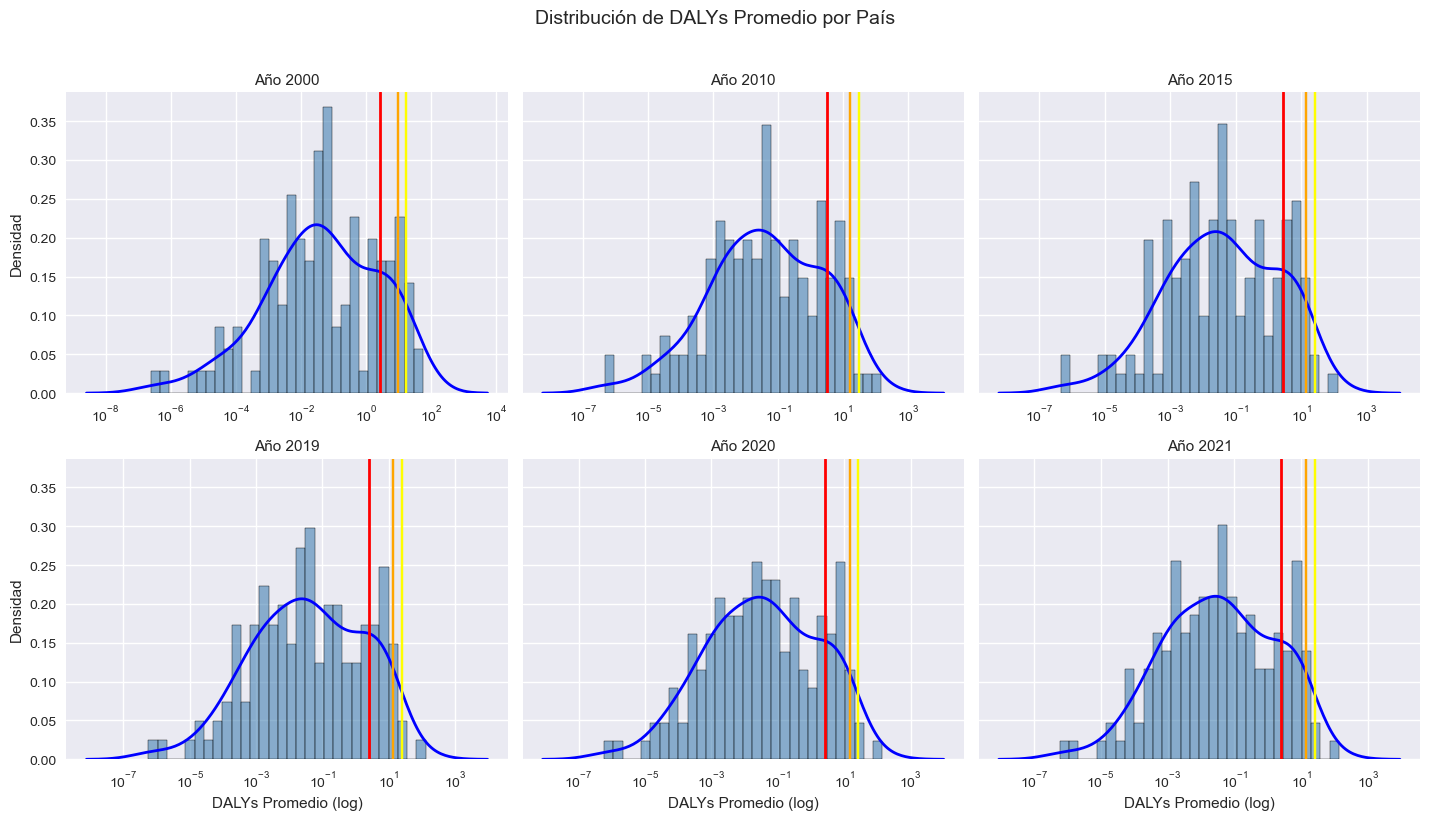

In [34]:
# Crear FacetGrid con KDE y líneas de estadísticas

# Función personalizada para agregar estadísticas
def plot_with_stats(data, **kwargs):
    """Grafica histograma + KDE con líneas de estadísticas"""
    # Graficar histograma y KDE
    sns.histplot(data, **kwargs)
    sns.kdeplot(data, color='blue', linewidth=2, log_scale=True)
    
    # Calcular estadísticas
    media = data.mean()
    desviacion = data.std()
    
    # Agregar líneas verticales
    plt.axvline(media, color='red', linestyle='-', linewidth=2, label=f'Media: {media:.2f}')
    plt.axvline(media+desviacion, color="orange", label="+/- 1 std")
    plt.axvline(media-desviacion, color="orange")
    plt.axvline(media+desviacion*2, color="yellow", label="+/- 2 std")
    plt.axvline(media-desviacion*2, color="yellow")
    
    plt.legend(loc='upper right', fontsize=7)


# Crear FacetGrid
g = sns.FacetGrid(dalys_por_pais_ano, col='ano', col_wrap=3, 
                  height=4, aspect=1.2, sharex=False)

# Aplicar función personalizada
g.map(plot_with_stats, 'dalys_promedio', bins=30, log_scale=True, 
      color='steelblue', alpha=0.6, stat='density')

g.set_axis_labels('DALYs Promedio (log)', 'Densidad')
g.set_titles(col_template='Año {col_name}')
g.fig.suptitle('Distribución de DALYs Promedio por País', y=1.02, fontsize=14)


plt.tight_layout()
plt.show()


In [ ]:
# Rango Intercuartil DALYs por año

# Calcular outliers por año usando groupby
def flag_outliers_iqr(group):
    q1 = group['dalys_promedio'].quantile(0.25)
    q3 = group['dalys_promedio'].quantile(0.75)
    iqr = q3 - q1
    group['outlier'] = (group['dalys_promedio'] < (q1 - 1.5 * iqr)) | (group['dalys_promedio'] > (q3 + 1.5 * iqr))
    return group


dalys_por_pais_ano = dalys_por_pais_ano.groupby('ano').apply(flag_outliers_iqr)

# Ver los outliers
outliers = dalys_por_pais_ano[dalys_por_pais_ano['outlier'] == True]
print(outliers[['ano', 'pais', 'dalys_promedio', 'outlier']])

            ano        pais  dalys_promedio  outlier
ano                                                 
2000 12    2000  Bangladesh        5.055804     True
     17    2000       Benin        5.054519     True
     22    2000      Brazil        4.937672     True
     26    2000     Burundi        8.661134     True
     29    2000    Cameroon       13.379488     True
...         ...         ...             ...      ...
2021 1081  2021       Sudan        5.550877     True
     1089  2021        Togo        2.323801     True
     1095  2021      Uganda       11.581772     True
     1106  2021       Yemen        1.838271     True
     1107  2021      Zambia        5.235578     True

[168 rows x 4 columns]


C:\Users\troop\AppData\Local\Temp\ipykernel_14012\2651423798.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dalys_por_pais_ano = dalys_por_pais_ano.groupby('ano').apply(flag_outliers_iqr)


#### Q-Q plot para distribución normal.

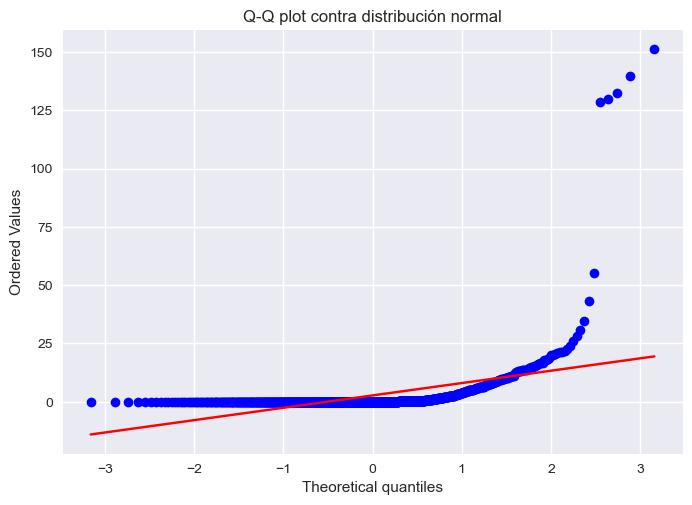

In [56]:
data = dalys_por_pais_ano['dalys_promedio'].dropna()
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q plot contra distribución normal")
plt.grid(True)
plt.show()



#### Q-Q plot para distribución Poisson.

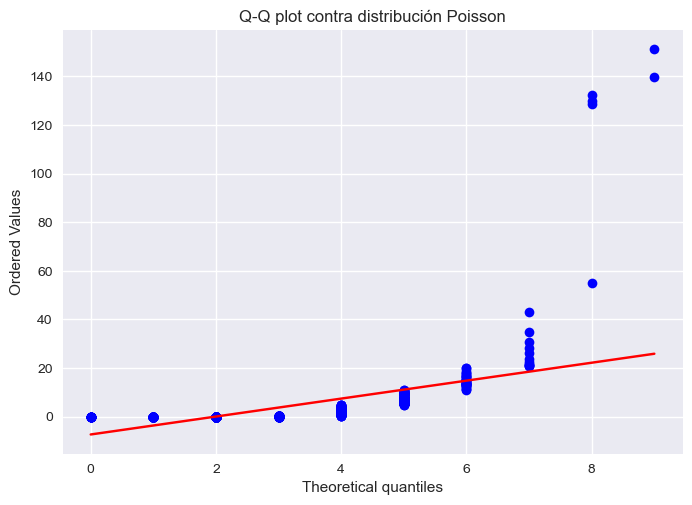

In [58]:
data = dalys_por_pais_ano['dalys_promedio'].dropna()
l_data = dalys_por_pais_ano['dalys_promedio'].mean()
stats.probplot(data, dist="poisson", sparams=(l_data,), plot=plt)
plt.title("Q-Q plot contra distribución Poisson")
plt.grid(True)
plt.show()

